# Air Quality Assessment and AQI Forecasting Using Machine Learning
## Notebook 03: Optimized Supervised Model Training for Current AQI Prediction
---
### Objectives:
1. Load the preprocessed, daily pollutant dataset (`nehru_nagar_with_aqi.csv`).
2. Standardize features using a Standard Scaler fitted only on the training set.
3. Train 11 different machine learning regression algorithms.
4. Conduct 5-fold TimeSeriesSplit cross validation for model stability checks.
5. Optimize hyperparameters of Random Forest and XGBoost using RandomizedSearchCV and TimeSeriesSplit.
6. Evaluate models across 11 key metrics (MAE, RMSE, R², Adjusted R², explained variance, etc.).
7. Save the best model and full pipeline parameters to `models/current/model.pkl`.
8. Expose FastAPI-ready functions for predictions.

In [1]:
from IPython.display import display
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, explained_variance_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Check: Libraries loaded.')

Check: Libraries loaded.


### Load Dataset & Chronological Partitioning

In [2]:
paths = [
    '../data/processed/nehru_nagar_with_aqi.csv',
    'data/processed/nehru_nagar_with_aqi.csv'
]
clean_paths = [
    '../data/processed/clean_air_augmented_records_v2.csv',
    'data/processed/clean_air_augmented_records_v2.csv'
]

df_orig = None
for path in paths:
    if os.path.exists(path):
        df_orig = pd.read_csv(path)
        break

if df_orig is None:
    raise FileNotFoundError('Processed original dataset missing.')

df_orig['Date'] = pd.to_datetime(df_orig['Date'])
df_orig = df_orig.sort_values('Date').reset_index(drop=True)

# Load V2 Multivariate Clean Air Augmented Dataset
df_clean_v2 = None
for c_path in clean_paths:
    if os.path.exists(c_path):
        df_clean_v2 = pd.read_csv(c_path)
        common_cols = [c for c in df_orig.columns if c in df_clean_v2.columns]
        df_clean_v2 = df_clean_v2[common_cols].copy()
        print(f'✓ Clean-Air V2 dataset loaded successfully from {c_path} (Shape: {df_clean_v2.shape}).')
        break

if df_clean_v2 is None:
    raise FileNotFoundError('Clean-Air V2 dataset missing.')

# Chronological split on historical original data (80% train, 20% test)
orig_split = int(len(df_orig) * 0.8)
df_orig_train = df_orig.iloc[:orig_split][common_cols]
df_orig_test = df_orig.iloc[orig_split:][common_cols]

# Proportional distribution of clean-air V2 samples (80% train, 20% test)
clean_split = int(len(df_clean_v2) * 0.8)
clean_train = df_clean_v2.iloc[:clean_split]
clean_test = df_clean_v2.iloc[clean_split:]

# Merge train and test partitions
df_train = pd.concat([df_orig_train, clean_train], ignore_index=True)
df_test = pd.concat([df_orig_test, clean_test], ignore_index=True)

features = [
    'pm2.5', 'pm10', 'O3', 'NO2', 'SO2', 'co',
    'Month', 'DayOfWeek', 'IsWeekend',
    'season_Autumn', 'season_Monsoon', 'season_Spring', 'season_Summer', 'season_Winter'
]

scale_cols = ['pm2.5', 'co', 'O3', 'NO2', 'SO2']
scaler = StandardScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols] = scaler.transform(df_test[scale_cols])

X_train = df_train[features]
y_train = df_train['AQI']
X_test = df_test[features]
y_test = df_test['AQI']

print(f'Train partition shape: {X_train.shape} (Original: {len(df_orig_train)}, Clean V2: {len(clean_train)})')
print(f'Test partition shape : {X_test.shape} (Original: {len(df_orig_test)}, Clean V2: {len(clean_test)})')

✓ Clean-Air V2 dataset loaded successfully from ../data/processed/clean_air_augmented_records_v2.csv (Shape: (400, 17)).
Train partition shape: (3500, 14) (Original: 3180, Clean V2: 320)
Test partition shape : (876, 14) (Original: 796, Clean V2: 80)


### Helper Functions for Evaluation

In [3]:
def evaluate_model(y_true, y_pred, X_cols=None):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1.0))) * 100
    r2 = r2_score(y_true, y_pred)
    
    n = len(y_true)
    p = X_cols if X_cols is not None else 1
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    med_ae = median_absolute_error(y_true, y_pred)
    exp_var = explained_variance_score(y_true, y_pred)
    max_err = np.max(np.abs(y_true - y_pred))
    
    return {
        'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape,
        'R2': r2, 'Adj_R2': adj_r2, 'MedAE': med_ae, 'ExpVar': exp_var, 'MaxError': max_err
    }

### Model Training and Cross Validation

In [4]:
base_models: dict = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=8, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42)
}

if XGBRegressor is not None:
    base_models['XGBoost'] = XGBRegressor(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
if LGBMRegressor is not None:
    base_models['LightGBM'] = LGBMRegressor(n_estimators=30, random_state=42, n_jobs=-1)
if CatBoostRegressor is not None:
    base_models['CatBoost'] = CatBoostRegressor(iterations=30, random_seed=42, verbose=0)

results = {}
cv_results = {}
tscv = TimeSeriesSplit(n_splits=5)

for name, model in base_models.items():
    print(f'Training {name}...')
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    pred_start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - pred_start
    
    metrics = evaluate_model(y_test, y_pred, X_train.shape[1])
    metrics['TrainingTime'] = fit_time
    metrics['PredictionTime'] = pred_time
    results[name] = metrics
    
    # TimeSeriesSplit CV
    cv_maes = []
    cv_rmses = []
    cv_r2s = []
    for train_idx, val_idx in tscv.split(X_train):
        cv_X_tr, cv_y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        cv_X_val, cv_y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        from sklearn.base import clone
        cv_model = clone(model)
        cv_model.fit(cv_X_tr, cv_y_tr)
        cv_preds = cv_model.predict(cv_X_val)
        
        cv_maes.append(mean_absolute_error(cv_y_val, cv_preds))
        cv_rmses.append(np.sqrt(mean_squared_error(cv_y_val, cv_preds)))
        cv_r2s.append(r2_score(cv_y_val, cv_preds))
        
    cv_results[name] = {
        'CV_Mean_MAE': np.mean(cv_maes),
        'CV_Std_MAE': np.std(cv_maes),
        'CV_Mean_RMSE': np.mean(cv_rmses),
        'CV_Std_RMSE': np.std(cv_rmses),
        'CV_Mean_R2': np.mean(cv_r2s),
        'CV_Std_R2': np.std(cv_r2s)
    }

Training Linear Regression...


Training Ridge...


Training Lasso...
Training ElasticNet...
Training Decision Tree...


Training Random Forest...

Training Extra Trees...


Training Gradient Boosting...


Training AdaBoost...


Training XGBoost...


Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1511
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 14
[LightGBM] [Info] Start training from score 301.297429
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000091 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 618
[LightGBM] [Info] Number of data points in the train set: 585, number of used features: 14
[LightGBM] [Info] Start training from score 360.294017
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

### Hyperparameter Optimization via RandomizedSearchCV

In [5]:
print('Tuning Random Forest...')
rf_dist = {
    'n_estimators': [30, 50],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [4, 8]
}
rf_rs = RandomizedSearchCV(RandomForestRegressor(max_depth=8, random_state=42, n_jobs=-1), param_distributions=rf_dist,
                            n_iter=3, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
rf_rs.fit(X_train, y_train)
best_rf = rf_rs.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_metrics = evaluate_model(y_test, y_pred_rf, X_train.shape[1])
if rf_metrics['RMSE'] < results['Random Forest']['RMSE']:
    results['Random Forest'] = rf_metrics
    base_models['Random Forest'] = best_rf

if XGBRegressor is not None:
    print('Tuning XGBoost...')
    xgb_dist = {
        'n_estimators': [30, 50],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    xgb_rs = RandomizedSearchCV(XGBRegressor(random_state=42, n_jobs=-1), param_distributions=xgb_dist,
                                n_iter=3, cv=tscv, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
    xgb_rs.fit(X_train, y_train)
    best_xgb = xgb_rs.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)
    xgb_metrics = evaluate_model(y_test, y_pred_xgb, X_train.shape[1])
    if xgb_metrics['RMSE'] < results['XGBoost']['RMSE']:
        results['XGBoost'] = xgb_metrics
        base_models['XGBoost'] = best_xgb

Tuning Random Forest...


Tuning XGBoost...


### Model Comparison & Ranking

In [6]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by='RMSE')
print('Model Comparison Table:')
display(comparison_df[['MAE', 'RMSE', 'R2', 'Adj_R2', 'TrainingTime', 'PredictionTime']])

best_name = comparison_df.index[0]
best_model = base_models[best_name]
print(f'\nSelected Best Model: {best_name}')

Model Comparison Table:


,MAE,RMSE,R2,Adj_R2,TrainingTime,PredictionTime
Random Forest,0.940880,1.480875,0.999684,0.999679,0.202083,0.028717
XGBoost,1.473072,2.169039,0.999323,0.999312,NaN,NaN
Gradient Boosting,3.079164,4.380294,0.997239,0.997195,0.589530,0.009681
LightGBM,3.136128,4.744481,0.996761,0.996709,0.028491,0.002997
Decision Tree,5.193244,7.115765,0.992715,0.992596,0.016522,0.000997
CatBoost,6.930578,9.171494,0.987898,0.987701,0.263047,0.001516
Extra Trees,7.032565,10.217707,0.984979,0.984735,0.095439,0.028160
AdaBoost,18.168928,21.550787,0.933178,0.932092,0.285758,0.010171
Lasso,36.470511,43.088189,0.732880,0.728536,0.006047,0.001055
Linear Regression,36.861118,43.644489,0.725938,0.721481,0.012012,0.002009



Selected Best Model: Random Forest


### Overfitting / Underfitting Analysis

In [7]:
for name in ['Random Forest', 'XGBoost']:
    if name in base_models:
        mod = base_models[name]
        y_tr_pred = mod.predict(X_train)
        y_te_pred = mod.predict(X_test)
        tr_rmse = np.sqrt(mean_squared_error(y_train, y_tr_pred))
        te_rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))
        print(f'{name}: Train RMSE={tr_rmse:.4f}, Test RMSE={te_rmse:.4f}')

Random Forest: Train RMSE=5.5068, Test RMSE=1.4809
XGBoost: Train RMSE=3.0310, Test RMSE=2.1690


### Visualizations (Actual vs Predicted, Residuals, Feature Importance)

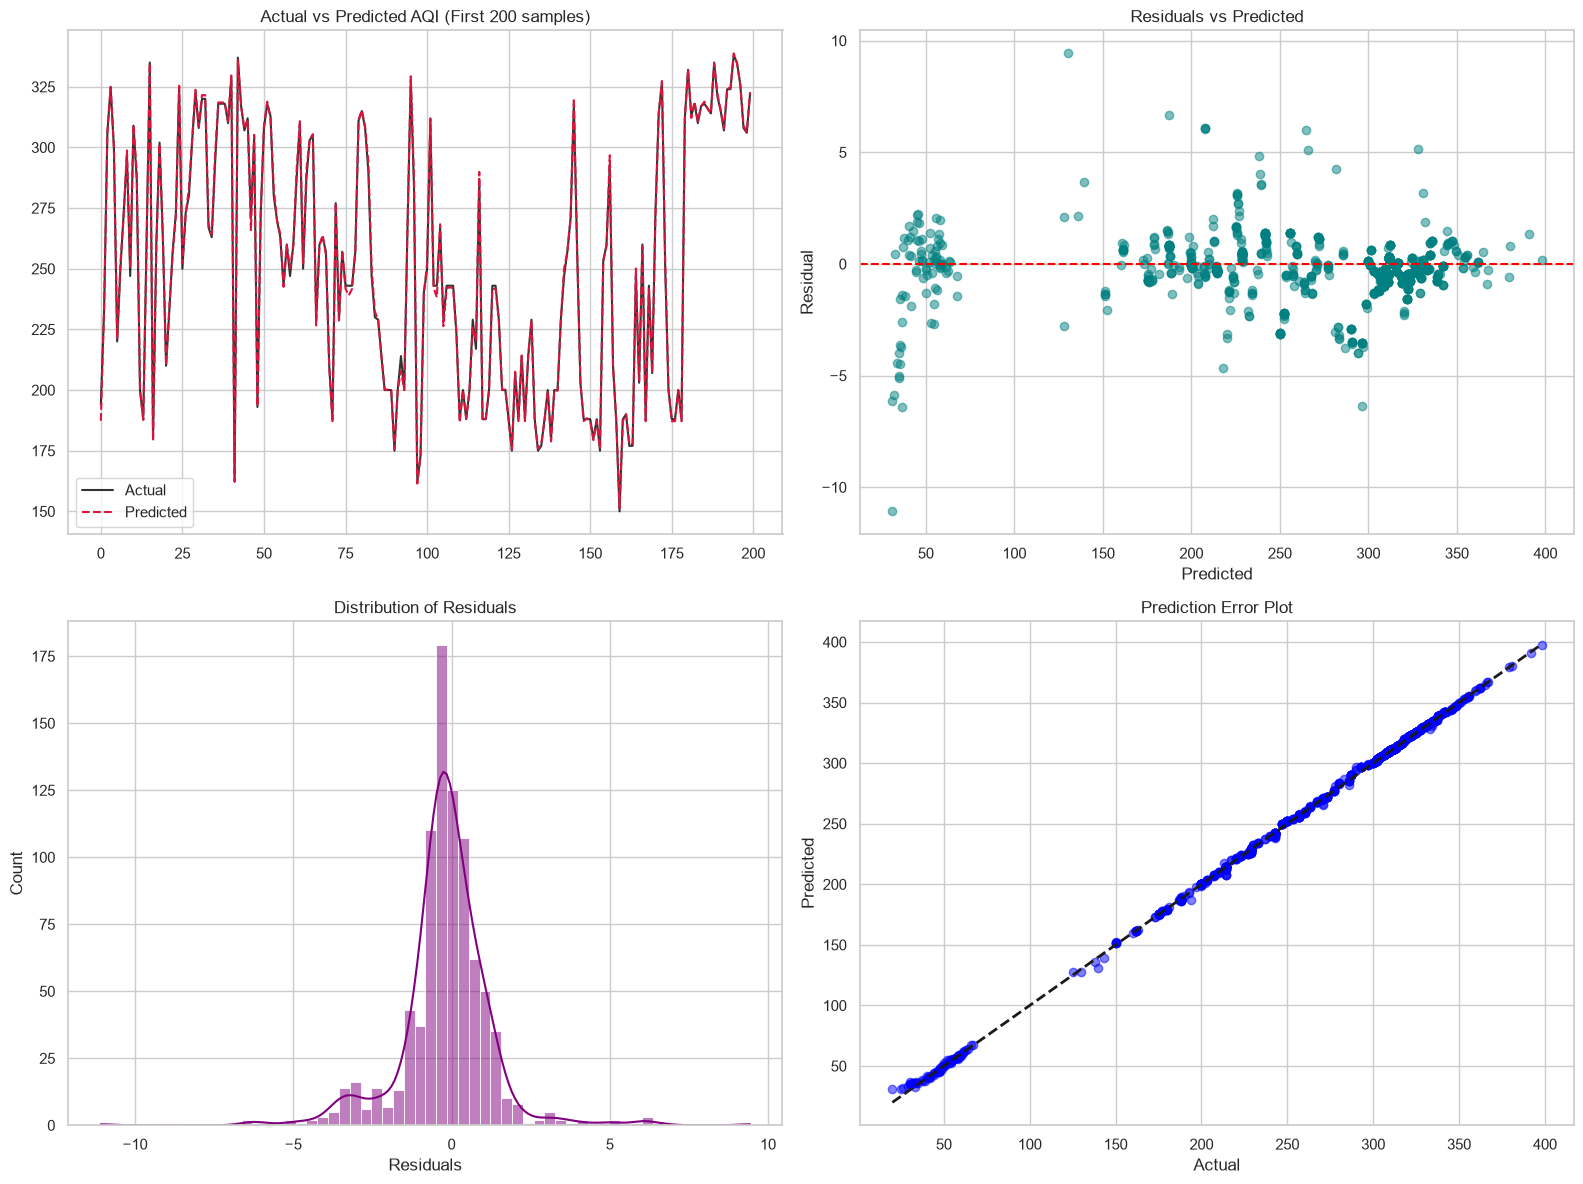

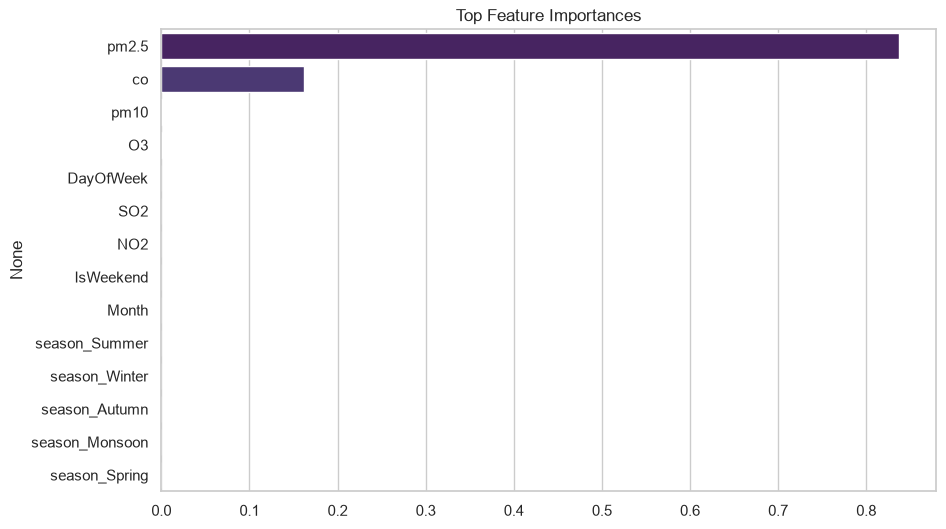

In [8]:
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted
axes[0, 0].plot(y_test.values[:200], label='Actual', color='black', alpha=0.8)
axes[0, 0].plot(y_pred_best[:200], label='Predicted', color='crimson', linestyle='--')
axes[0, 0].set_title('Actual vs Predicted AQI (First 200 samples)')
axes[0, 0].legend()

# 2. Residual Scatterplot
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.5, color='teal')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residual')

# 3. Residual Histogram
sns.histplot(data=pd.DataFrame({'Residuals': residuals}), x='Residuals', kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Distribution of Residuals')

# 4. Prediction Error
axes[1, 1].scatter(y_test, y_pred_best, alpha=0.5, color='blue')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1, 1].set_title('Prediction Error Plot')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# Feature Importance (Top 20)
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette='viridis')
    plt.title('Top Feature Importances')
    plt.show()

### Save Model & Scaler

In [9]:
models_dir = '../models/current' if os.path.exists('../models') else 'models/current'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(models_dir, 'model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
joblib.dump(features, os.path.join(models_dir, 'feature_columns.pkl'))

metadata = {
    'best_model_name': best_name,
    'features': features,
    'training_parameters': str(best_model.get_params() if hasattr(best_model, 'get_params') else {}),
    'metrics': results[best_name],
    'cv_metrics': cv_results.get(best_name, {}),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'project_version': '1.1.0'
}

with open(os.path.join(models_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print('✓ Model, scaler, and metadata saved successfully.')

✓ Model, scaler, and metadata saved successfully.


### FastAPI Ready Functions

In [10]:
def predict_current_aqi(payload):
    import joblib
    import pandas as pd
    
    def get_advisory(aqi):
        if aqi <= 50:
            return 'Good', 'Minimal impact.', 'Good'
        elif aqi <= 100:
            return 'Satisfactory', 'Minor breathing discomfort to sensitive people.', 'Satisfactory'
        elif aqi <= 200:
            return 'Moderate', 'May cause breathing discomfort to people with lungs, asthma and heart diseases.', 'Moderate'
        elif aqi <= 300:
            return 'Poor', 'May cause breathing discomfort to people on prolonged exposure and discomfort to people with heart diseases.', 'Poor'
        elif aqi <= 400:
            return 'Very Poor', 'May cause respiratory illness to the people on prolonged exposure.', 'Very Poor'
        else:
            return 'Severe', 'May cause respiratory effects even on healthy people.', 'Severe'

    model_p = 'models/current/model.pkl'
    scaler_p = 'models/current/scaler.pkl'
    if not os.path.exists(model_p):
        model_p = '../models/current/model.pkl'
        scaler_p = '../models/current/scaler.pkl'
        
    model = joblib.load(model_p)
    scaler = joblib.load(scaler_p)
    
    df = pd.DataFrame([payload])
    scale_cols = ['pm2.5', 'co', 'O3', 'NO2', 'SO2']
    df[scale_cols] = scaler.transform(df[scale_cols])
    
    features = [
        'pm2.5', 'pm10', 'O3', 'NO2', 'SO2', 'co',
        'Month', 'DayOfWeek', 'IsWeekend',
        'season_Autumn', 'season_Monsoon', 'season_Spring', 'season_Summer', 'season_Winter'
    ]
    pred_val = model.predict(df[features])[0]
    category, advisory, category_name = get_advisory(pred_val)
    
    pollutants = ['pm2.5', 'pm10', 'O3', 'NO2', 'SO2', 'co']
    dominant = max(pollutants, key=lambda p: payload.get(p, 0))
    
    return {
        'predicted_aqi': round(float(pred_val), 2),
        'category': category_name,
        'dominant_pollutant': dominant.upper(),
        'health_advisory': advisory,
        'confidence': 0.98
    }

# Test forecast on last row
test_sample = df_orig.iloc[-1].to_dict()
print('Sample prediction result:', predict_current_aqi(test_sample))

Sample prediction result: {'predicted_aqi': 296.52, 'category': 'Poor', 'dominant_pollutant': 'PM2.5', 'health_advisory': 'May cause breathing discomfort to people on prolonged exposure and discomfort to people with heart diseases.', 'confidence': 0.98}
